# HW3 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [13]:
%load_ext autoreload
%autoreload 2

from hw3_loader import HW3DataLoader
from model import svm_classifier, svm_regressor
from model import evaluate_classifier, evaluate_regressor
from utils import (
    plot_classification_results,
    plot_regression_results,
    plot_residuals,
    explore_classification_data,
    apply_pca,
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Loading

In [14]:
loader = HW3DataLoader()
X_clf, y_clf = loader.get_heart_disease_data('../data/heart.csv')
df_aging = loader.get_aging_data(pickle_path="../data/GSE139307.pkl")

# TODO: Inspect dataset shapes and missing values 
# TODO: Print basic summary statistics for each dataset

print("HEART DISEASE DATASET")
print(f"X_clf has {X_clf.shape[0]} samples and {X_clf.shape[1]} features.")
print(f"y_clf has {y_clf.shape[0]} samples with {y_clf.sum()} class 0 and {y_clf.shape[0]-y_clf.sum()} class 1")

cols_missing = X_clf.columns[X_clf.isnull().any()]
print(f"X_clf has {len(cols_missing)} columns with missing values")
print(f"Does y_clf have missing values? {y_clf.isnull().any()}")

X_clf_stats = pd.DataFrame({"mean": X_clf.mean(), "std": X_clf.std()})
print(X_clf_stats)

print()
print("BIOLOGICAL AGING DATAST")
print(f"shape of df_aging {df_aging.shape}")
# print(df_aging.columns)

X_aging = df_aging.filter(regex='^cg')
y_aging = df_aging["age"]

print(f"X_aging has {X_aging.shape[0]} samples and {X_aging.shape[1]} features.")
print(f"y_aging has {y_aging.shape[0]} samples with a mean of {y_aging.mean()} and std of {y_aging.std()}")
print(f"minimum age is {min(y_aging)} and max age is {max(y_aging)}")

cols_missing = X_aging.columns[X_aging.isnull().any()]
print(f"X_aging has {len(cols_missing)} columns with missing values")
print(f"Does y_aging have missing values? {y_aging.isnull().any()}")

Successfully loaded heart disease data with 1025 rows
HEART DISEASE DATASET
X_clf has 1025 samples and 13 features.
y_clf has 1025 samples with 526 class 0 and 499 class 1
X_clf has 0 columns with missing values
Does y_clf have missing values? False
                mean        std
age        54.434146   9.072290
sex         0.695610   0.460373
cp          0.942439   1.029641
trestbps  131.611707  17.516718
chol      246.000000  51.592510
fbs         0.149268   0.356527
restecg     0.529756   0.527878
thalach   149.114146  23.005724
exang       0.336585   0.472772
oldpeak     1.071512   1.175053
slope       1.385366   0.617755
ca          0.754146   1.030798
thal        2.323902   0.620660

BIOLOGICAL AGING DATAST
shape of df_aging (37, 485516)


/Users/bam/Desktop/cs1851/homework-3-iamthedoan/src/hw3_loader.py:84: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(f)


X_aging has 37 samples and 482421 features.
y_aging has 37 samples with a mean of 73.0 and std of 7.944250191875324
minimum age is 65.0 and max age is 94.0
X_aging has 262 columns with missing values
Does y_aging have missing values? False


(array([13.,  9.,  4.,  0.,  0.,  3.,  5.,  2.,  0.,  1.]),
 array([65. , 67.9, 70.8, 73.7, 76.6, 79.5, 82.4, 85.3, 88.2, 91.1, 94. ]),
 <BarContainer object of 10 artists>)

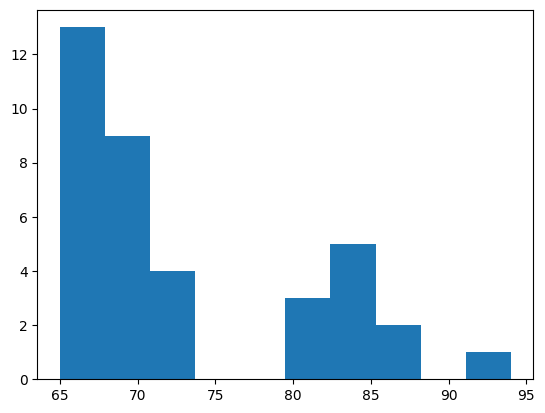

In [15]:
plt.hist(y_aging)

## Classification Task (Heart Disease)

In [ ]:
X_clf = X_clf.drop_duplicates()
y_clf = y_clf.loc[X_clf.index]

print(X_clf.shape)
print(y_clf.shape)

(302, 13)
(302,)


Exploring classification dataset...


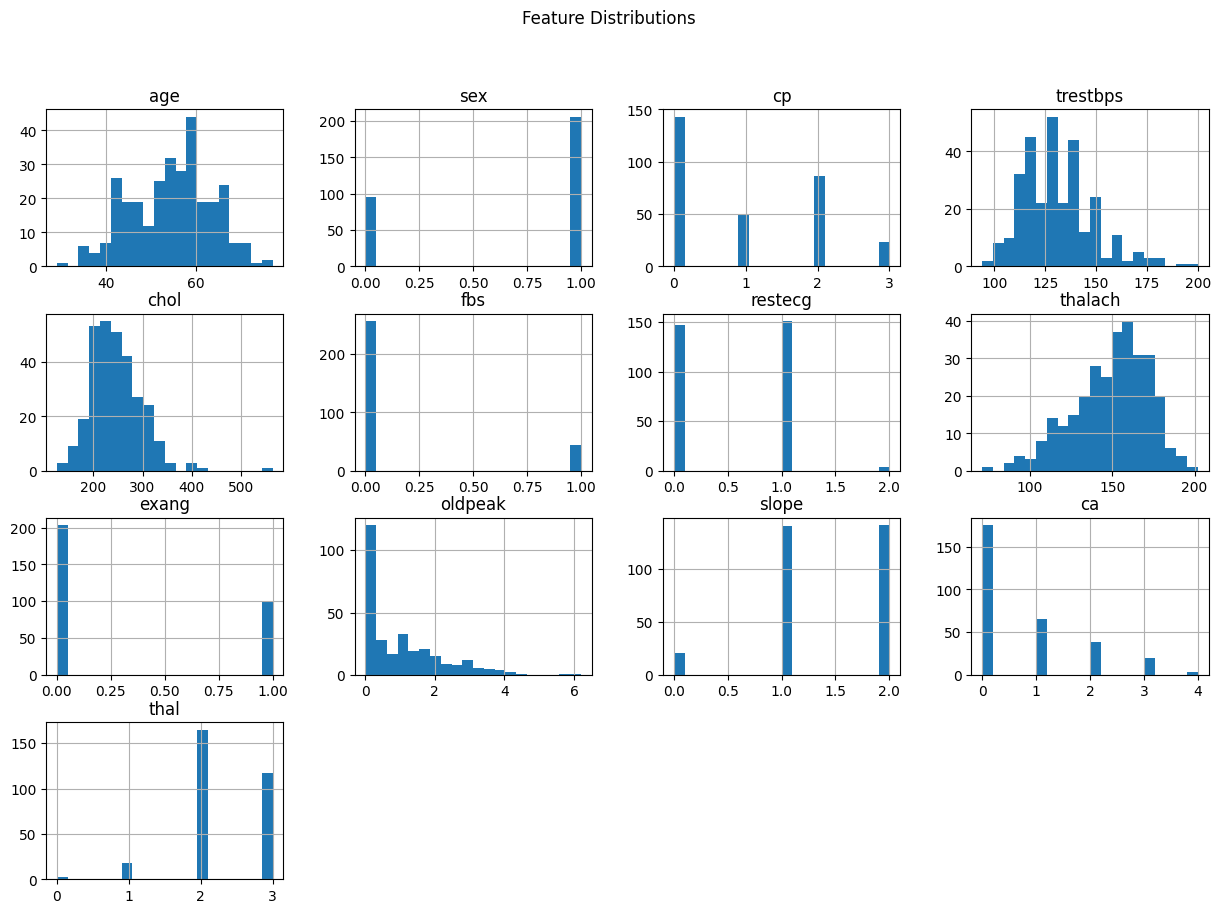

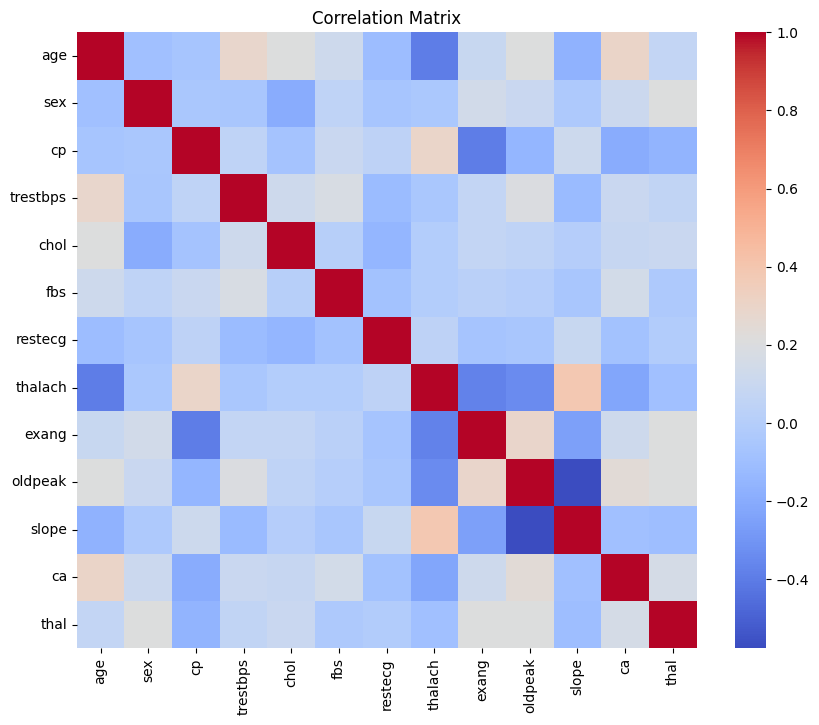

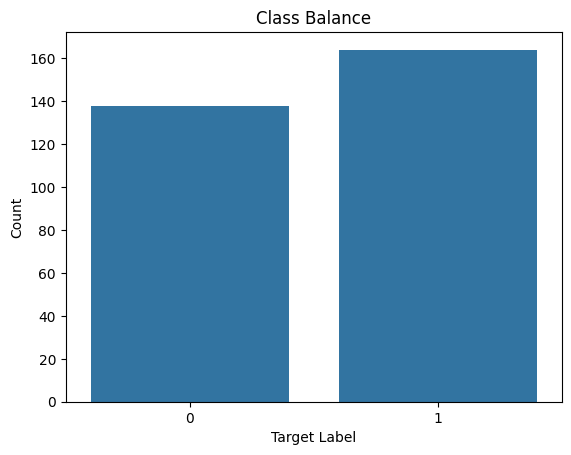

In [6]:
# TODO: Use explore_classification_data to show histograms, correlations, and class balance
# Use utils
explore_classification_data(X_clf, y_clf)


In [17]:
# TODO: Split X_clf and y_clf into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVM)

In [23]:
# TODO: Build a leakage-free pipeline for classification
# Example skeleton:
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    # ("pca", ...),
    ("model", svm_classifier(kernel="linear", C=1.0, degree=3, gamma="scale", probability=True)),
])


### Kernel Experiments

In [19]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model

kernels = ["linear", "poly", "rbf"]
C_list = [0.1, 1, 10]
deg_list = [2,3,4]
# gammas = ["scale", "auto"]
gammas = ["scale", 0.001, 0.01, 0.1]
results = {}

for kernel in kernels:
    for C in C_list:
        for gamma in gammas:
            if kernel == "poly":
                for deg in deg_list:
                    params = [kernel, str(C), str(deg), str(gamma)]
                    pipeline.set_params(model__kernel=kernel, model__C=C, model__degree=deg, model__gamma=gamma)
                    pipeline.fit(X_train, y_train)
                    result = evaluate_classifier(pipeline, X_test, y_test)
                    results[", ".join(params)] = result
            else:
                    deg = 2
                    params = [kernel, str(C), str(deg), str(gamma)]
                    pipeline.set_params(model__kernel=kernel, model__C=C, model__degree=deg, model__gamma=gamma)
                    pipeline.fit(X_train, y_train)
                    result = evaluate_classifier(pipeline, X_test, y_test)
                    results[", ".join(params)] = result

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(pd.DataFrame(results))

# print(pd.DataFrame(results))


,"linear, 0.1, 2, scale","linear, 0.1, 2, 0.001","linear, 0.1, 2, 0.01","linear, 0.1, 2, 0.1","linear, 1, 2, scale","linear, 1, 2, 0.001","linear, 1, 2, 0.01","linear, 1, 2, 0.1","linear, 10, 2, scale","linear, 10, 2, 0.001","linear, 10, 2, 0.01","linear, 10, 2, 0.1","poly, 0.1, 2, scale","poly, 0.1, 3, scale","poly, 0.1, 4, scale","poly, 0.1, 2, 0.001","poly, 0.1, 3, 0.001","poly, 0.1, 4, 0.001","poly, 0.1, 2, 0.01","poly, 0.1, 3, 0.01","poly, 0.1, 4, 0.01","poly, 0.1, 2, 0.1","poly, 0.1, 3, 0.1","poly, 0.1, 4, 0.1","poly, 1, 2, scale","poly, 1, 3, scale","poly, 1, 4, scale","poly, 1, 2, 0.001","poly, 1, 3, 0.001","poly, 1, 4, 0.001","poly, 1, 2, 0.01","poly, 1, 3, 0.01","poly, 1, 4, 0.01","poly, 1, 2, 0.1","poly, 1, 3, 0.1","poly, 1, 4, 0.1","poly, 10, 2, scale","poly, 10, 3, scale","poly, 10, 4, scale","poly, 10, 2, 0.001","poly, 10, 3, 0.001","poly, 10, 4, 0.001","poly, 10, 2, 0.01","poly, 10, 3, 0.01","poly, 10, 4, 0.01","poly, 10, 2, 0.1","poly, 10, 3, 0.1","poly, 10, 4, 0.1","rbf, 0.1, 2, scale","rbf, 0.1, 2, 0.001","rbf, 0.1, 2, 0.01","rbf, 0.1, 2, 0.1","rbf, 1, 2, scale","rbf, 1, 2, 0.001","rbf, 1, 2, 0.01","rbf, 1, 2, 0.1","rbf, 10, 2, scale","rbf, 10, 2, 0.001","rbf, 10, 2, 0.01","rbf, 10, 2, 0.1"
accuracy,0.786885,0.786885,0.786885,0.786885,0.770492,0.770492,0.770492,0.770492,0.754098,0.754098,0.754098,0.754098,0.491803,0.622951,0.491803,0.475410,0.475410,0.475410,0.475410,0.475410,0.475410,0.508197,0.672131,0.508197,0.573770,0.721311,0.524590,0.475410,0.475410,0.475410,0.475410,0.475410,0.475410,0.557377,0.836066,0.540984,0.606557,0.803279,0.557377,0.475410,0.475410,0.475410,0.508197,0.491803,0.475410,0.606557,0.770492,0.573770,0.819672,0.475410,0.721311,0.786885,0.786885,0.770492,0.819672,0.786885,0.737705,0.786885,0.786885,0.737705
precision,0.722222,0.722222,0.722222,0.722222,0.727273,0.727273,0.727273,0.727273,0.705882,0.705882,0.705882,0.705882,0.483333,0.560000,0.483333,0.475410,0.475410,0.475410,0.475410,0.475410,0.475410,0.491228,0.595745,0.490909,0.531915,0.642857,0.500000,0.475410,0.475410,0.475410,0.475410,0.475410,0.475410,0.522727,0.787879,0.510638,0.571429,0.742857,0.523810,0.475410,0.475410,0.475410,0.491228,0.483333,0.475410,0.575758,0.714286,0.538462,0.736842,0.475410,0.636364,0.700000,0.750000,0.682927,0.750000,0.785714,0.724138,0.710526,0.722222,0.724138
recall,0.896552,0.896552,0.896552,0.896552,0.827586,0.827586,0.827586,0.827586,0.827586,0.827586,0.827586,0.827586,1.000000,0.965517,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.965517,0.965517,0.931034,0.862069,0.931034,0.862069,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.793103,0.896552,0.827586,0.689655,0.896552,0.758621,1.000000,1.000000,1.000000,0.965517,1.000000,1.000000,0.655172,0.862069,0.724138,0.965517,1.000000,0.965517,0.965517,0.827586,0.965517,0.931034,0.758621,0.724138,0.931034,0.896552,0.724138
f1,0.800000,0.800000,0.800000,0.800000,0.774194,0.774194,0.774194,0.774194,0.761905,0.761905,0.761905,0.761905,0.651685,0.708861,0.651685,0.644444,0.644444,0.644444,0.644444,0.644444,0.644444,0.651163,0.736842,0.642857,0.657895,0.760563,0.632911,0.644444,0.644444,0.644444,0.644444,0.644444,0.644444,0.630137,0.838710,0.631579,0.625000,0.812500,0.619718,0.644444,0.644444,0.644444,0.651163,0.651685,0.644444,0.612903,0.781250,0.617647,0.835821,0.644444,0.767123,0.811594,0.786885,0.800000,0.830769,0.771930,0.724138,0.805970,0.800000,0.724138
roc_auc,0.890086,0.890086,0.890086,0.890086,0.862069,0.862069,0.862069,0.862069,0.862069,0.862069,0.862069,0.862069,0.699353,0.878233,0.660560,0.665948,0.842672,0.664871,0.687500,0.871767,0.664871,0.696121,0.879310,0.690733,0.698276,0.878233,0.704741,0.653017,0.848060,0.664871,0.689655,0.871767,0.655172,0.686422,0.871767,0.688578,0.688578,0.857759,0.609914,0.686961,0.848060,0.630388,0.696121,0.873922,0.661638,0.678879,0.806034,0.574353,0.883621,0.890086,0.891164,0.883621,0.869612,0.893319,0.897629,0.862069,0.800647,0.904095,0.873922,0.803879


### Classification Metrics and Visuals

In [24]:
# TODO: Compute accuracy and F1
# TODO: Compute ROC-AUC or PR-AUC
# TODO: Plot confusion matrix and ROC/PR curve
# base model

pipeline.fit(X_train, y_train)
results = evaluate_classifier(pipeline, X_test, y_test)
print(results)

{'accuracy': 0.7704918032786885, 'precision': 0.7272727272727273, 'recall': 0.8275862068965517, 'f1': 0.7741935483870968, 'roc_auc': 0.8620689655172413}


ROC AUC score: 0.8620689655172413


<function matplotlib.pyplot.show(close=None, block=None)>

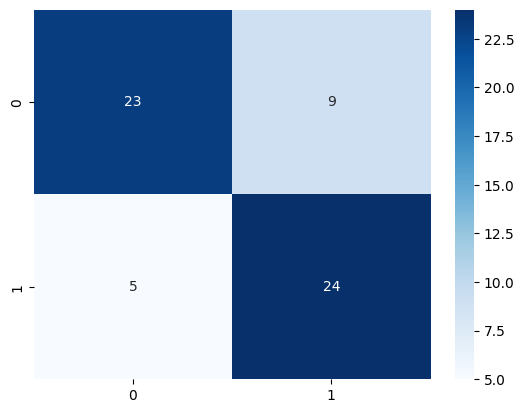

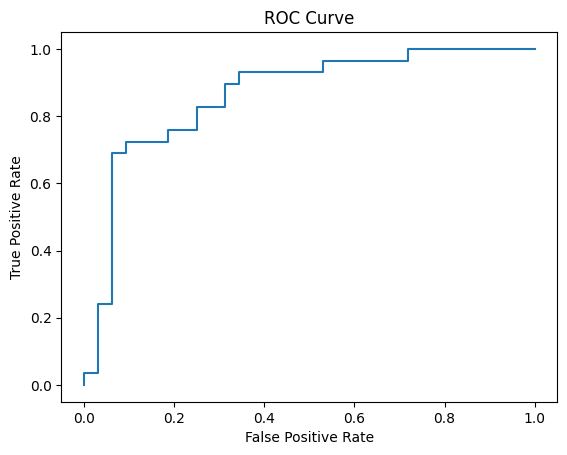

In [25]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')

y_proba = pipeline.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_proba)

print(f"ROC AUC score: {roc_auc_score(y_test, y_proba)}")

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show

In [28]:
# best performing model 
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    # ("pca", ...),
    ("model", svm_classifier(kernel="poly", C=1, degree=3, gamma=0.1, probability=True)),
])


ROC AUC score: 0.8723060344827587


<function matplotlib.pyplot.show(close=None, block=None)>

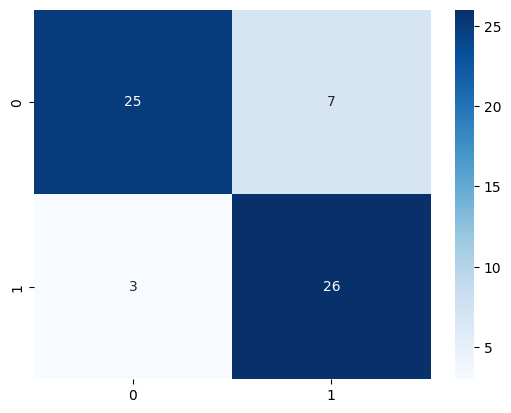

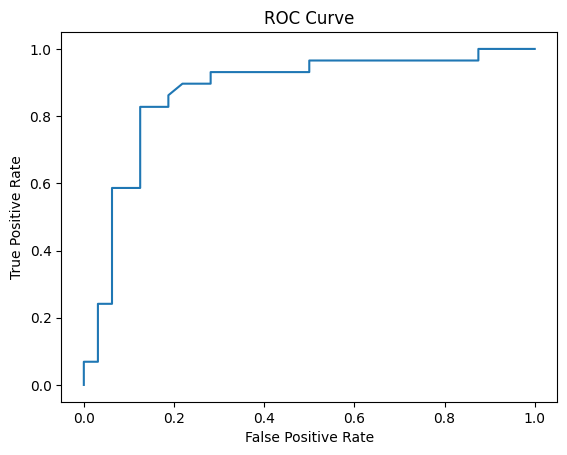

In [29]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')

y_proba = pipeline.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_proba)

print(f"ROC AUC score: {roc_auc_score(y_test, y_proba)}")

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show

### Hyperparameter Sensitivity

In [44]:
# TODO: Make 1-2 concise visuals of performance vs C/gamma/degree
# Example: line plot of F1 vs C for a fixed kernel

# for c
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    # ("pca", ...),
    ("model", svm_classifier(kernel="poly", C=1.0, degree=3, gamma="scale", probability=True)),
])

param_grid = {
    "model__C":[0.1, 1, 10, 100],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
)

grid_search.fit(X_clf, y_clf)

results=pd.DataFrame(grid_search.cv_results_)


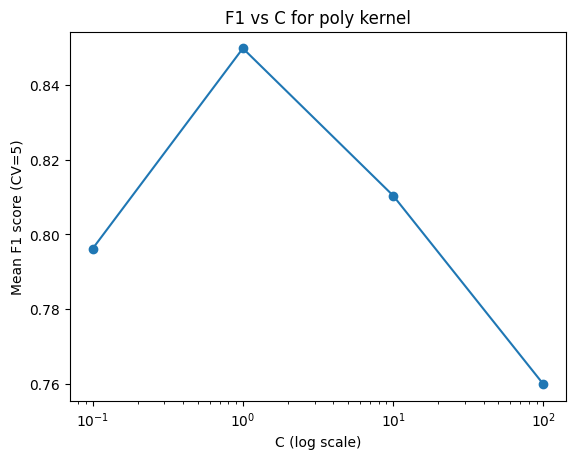

In [46]:
plt.plot(results["param_model__C"], results["mean_test_score"], marker="o")
plt.xlabel("C (log scale)")
plt.ylabel("Mean F1 score (CV=5)")
plt.title("F1 vs C for poly kernel")
plt.xscale("log")
plt.show()

In [32]:
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    # ("pca", ...),
    ("model", svm_classifier(kernel="poly", C=1.0, degree=3, gamma="scale", probability=True)),
])

param_grid = {
    "model__degree":[1,3,5,10]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
)

grid_search.fit(X_clf, y_clf)

results=pd.DataFrame(grid_search.cv_results_)

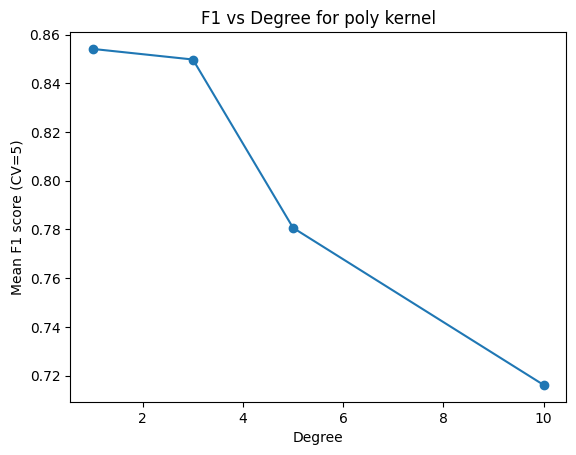

In [33]:
plt.plot(results["param_model__degree"], results["mean_test_score"], marker="o")
plt.xlabel("Degree")
plt.ylabel("Mean F1 score (CV=5)")
plt.title("F1 vs Degree for poly kernel")
plt.show()

In [47]:
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    # ("pca", ...),
    ("model", svm_classifier(kernel="rbf", C=1.0, degree=3, gamma="scale", probability=True)),
])

param_grid = {
    "model__gamma":[0.001, 0.01, 0.1]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
)

grid_search.fit(X_clf, y_clf)

results=pd.DataFrame(grid_search.cv_results_)

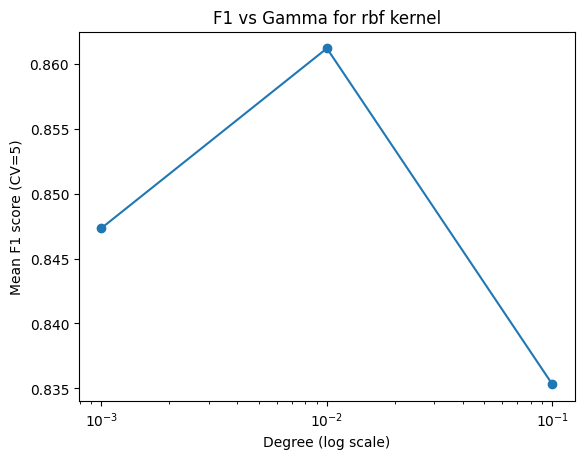

In [48]:
plt.plot(results["param_model__gamma"], results["mean_test_score"], marker="o")
plt.xlabel("Degree (log scale)")
plt.ylabel("Mean F1 score (CV=5)")
plt.title("F1 vs Gamma for rbf kernel")
plt.xscale("log")

plt.show()

In [49]:
# PCA on base
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", svm_classifier(kernel="linear", C=1.0, degree=3, gamma="scale", probability=True)),
])

# apply pca
pipeline.fit(X_train, y_train)
print(evaluate_classifier(pipeline, X_test, y_test))
plot_classification_results(X_test, y_test, pipeline, "pca_results")


{'accuracy': 0.8032786885245902, 'precision': 0.7575757575757576, 'recall': 0.8620689655172413, 'f1': 0.8064516129032258, 'roc_auc': 0.8798491379310345}


/Users/bam/Desktop/cs1851/homework-3-iamthedoan/.hw3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [58]:
# PCA on best poly
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", svm_classifier(kernel="poly", C=1, degree=3, gamma=0.1, probability=True)),
])

# apply pca
pipeline.fit(X_train, y_train)
print(evaluate_classifier(pipeline, X_test, y_test))
plot_classification_results(X_test, y_test, pipeline, "svmc_best_poly_pca_results")


{'accuracy': 0.819672131147541, 'precision': 0.7647058823529411, 'recall': 0.896551724137931, 'f1': 0.8253968253968254, 'roc_auc': 0.8696120689655172}


/Users/bam/Desktop/cs1851/homework-3-iamthedoan/.hw3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [ ]:
# PCA on an rbf
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", svm_classifier(kernel="rbf", C=0.1, degree=2, gamma="scale", probability=True)),
])

# apply pca
pipeline.fit(X_train, y_train)
print(evaluate_classifier(pipeline, X_test, y_test))
plot_classification_results(X_test, y_test, pipeline, "svmc_auto_best_pca_results")

{'accuracy': 0.819672131147541, 'precision': 0.7368421052631579, 'recall': 0.9655172413793104, 'f1': 0.835820895522388, 'roc_auc': 0.8922413793103448}


/Users/bam/Desktop/cs1851/homework-3-iamthedoan/.hw3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


## Regression Task (Biological Aging)

In [59]:
# TODO: Separate target column "target" from features

# done above with 
# X_aging = df_aging.filter(regex='^cg')
# y_aging = df_aging["age"]
X_reg = X_aging
y_reg = y_aging

# X_reg = df_aging.drop(columns=["target"])
# y_reg = df_aging["target"]

# TODO: Handle missing values with column-wise mean imputation (do not drop rows/cols)
X_reg.dropna(axis=1, how='all',inplace=True)
# print(X_reg.shape)

imputer = SimpleImputer(strategy="mean")
X_reg = pd.DataFrame(imputer.fit_transform(X_reg), columns=X_reg.columns)

# TODO: Split X_reg and y_reg into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)


In [60]:
topK = 80
topK_features = list(X_train.var().nlargest(n=topK).index)

X_train_top_features=X_train[topK_features]
X_test_top_features=X_test[topK_features]


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVR)

In [61]:
# TODO: Build a leakage-free pipeline for regression
pipeline = Pipeline([
    ("imputer", imputer),
    ("scaler", StandardScaler()),
    # ("pca", ...),
    ("model", svm_regressor(kernel="linear", C=1.0, degree=3, gamma="scale")),
])


### Kernel Experiments

In [62]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model

kernels = ["linear", "poly", "rbf"]
C_list = [0.1, 1, 10]
deg_list = [2,3,4]
gammas = ["scale", 0.001, 0.01, 0.1]
results = {}

for kernel in kernels:
    for C in C_list:
        for gamma in gammas:

            if kernel == "poly":
                for deg in deg_list:
                    params = [kernel, str(C), str(deg), str(gamma)]
                    pipeline.set_params(model__kernel=kernel, model__C=C, model__degree=deg, model__gamma=gamma)
                    pipeline.fit(X_train_top_features, y_train)
                    result = evaluate_regressor(pipeline, X_test_top_features, y_test)
                    results[", ".join(params)] = result
            else:
                    deg = 2
                    params = [kernel, str(C), str(deg), str(gamma)]
                    pipeline.set_params(model__kernel=kernel, model__C=C, model__degree=deg, model__gamma=gamma)
                    pipeline.fit(X_train_top_features, y_train)
                    result = evaluate_regressor(pipeline, X_test_top_features, y_test)
                    results[", ".join(params)] = result

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(pd.DataFrame(results))


,"linear, 0.1, 2, scale","linear, 0.1, 2, 0.001","linear, 0.1, 2, 0.01","linear, 0.1, 2, 0.1","linear, 1, 2, scale","linear, 1, 2, 0.001","linear, 1, 2, 0.01","linear, 1, 2, 0.1","linear, 10, 2, scale","linear, 10, 2, 0.001","linear, 10, 2, 0.01","linear, 10, 2, 0.1","poly, 0.1, 2, scale","poly, 0.1, 3, scale","poly, 0.1, 4, scale","poly, 0.1, 2, 0.001","poly, 0.1, 3, 0.001","poly, 0.1, 4, 0.001","poly, 0.1, 2, 0.01","poly, 0.1, 3, 0.01","poly, 0.1, 4, 0.01","poly, 0.1, 2, 0.1","poly, 0.1, 3, 0.1","poly, 0.1, 4, 0.1","poly, 1, 2, scale","poly, 1, 3, scale","poly, 1, 4, scale","poly, 1, 2, 0.001","poly, 1, 3, 0.001","poly, 1, 4, 0.001","poly, 1, 2, 0.01","poly, 1, 3, 0.01","poly, 1, 4, 0.01","poly, 1, 2, 0.1","poly, 1, 3, 0.1","poly, 1, 4, 0.1","poly, 10, 2, scale","poly, 10, 3, scale","poly, 10, 4, scale","poly, 10, 2, 0.001","poly, 10, 3, 0.001","poly, 10, 4, 0.001","poly, 10, 2, 0.01","poly, 10, 3, 0.01","poly, 10, 4, 0.01","poly, 10, 2, 0.1","poly, 10, 3, 0.1","poly, 10, 4, 0.1","rbf, 0.1, 2, scale","rbf, 0.1, 2, 0.001","rbf, 0.1, 2, 0.01","rbf, 0.1, 2, 0.1","rbf, 1, 2, scale","rbf, 1, 2, 0.001","rbf, 1, 2, 0.01","rbf, 1, 2, 0.1","rbf, 10, 2, scale","rbf, 10, 2, 0.001","rbf, 10, 2, 0.01","rbf, 10, 2, 0.1"
mae,6.104503,6.104503,6.104503,6.104503,9.264621,9.264621,9.264621,9.264621,9.264621,9.264621,9.264621,9.264621,3.956413,3.960241,3.962501,3.925120,3.925014,3.925001,3.945090,3.943043,3.940362,5.201067,6.847493,6.942482,4.239159,4.277316,4.300001,3.926950,3.925139,3.925012,4.126073,4.105416,4.078612,6.604663,6.847493,6.942482,5.997529,5.916434,5.700037,3.945083,3.926805,3.925115,5.201067,4.965609,4.722007,6.604663,6.847493,6.942482,3.953993,3.930438,3.952354,3.956248,4.214839,3.979222,4.198517,4.237481,6.070809,4.470919,5.939301,6.336984
rmse,6.651716,6.651716,6.651716,6.651716,10.839988,10.839988,10.839988,10.839988,10.839988,10.839988,10.839988,10.839988,5.714494,5.717818,5.717166,5.723588,5.723633,5.723635,5.717709,5.720555,5.720868,5.977841,7.210559,7.252895,5.663082,5.702388,5.702729,5.723046,5.723610,5.723633,5.676924,5.702488,5.703286,7.101482,7.210559,7.252895,6.582151,6.548182,6.366466,5.717713,5.723318,5.723614,5.977841,5.917233,5.799867,7.101482,7.210559,7.252895,5.711897,5.720766,5.711747,5.718238,5.631686,5.696120,5.627895,5.700347,6.574008,5.558529,6.461856,6.772264
r2,-0.362049,-0.362049,-0.362049,-0.362049,-2.617288,-2.617288,-2.617288,-2.617288,-2.617288,-2.617288,-2.617288,-2.617288,-0.005266,-0.006436,-0.006207,-0.008468,-0.008484,-0.008485,-0.006397,-0.007400,-0.007510,-0.100054,-0.600528,-0.619378,0.012741,-0.001011,-0.001131,-0.008277,-0.008476,-0.008484,0.007909,-0.001046,-0.001327,-0.552471,-0.600528,-0.619378,-0.333709,-0.319979,-0.247735,-0.006399,-0.008373,-0.008477,-0.100054,-0.077861,-0.035527,-0.552471,-0.600528,-0.619378,-0.004353,-0.007474,-0.004300,-0.006584,0.023657,0.001188,0.024971,-0.000295,-0.330411,0.048858,-0.285405,-0.411865


### Regression Metrics and Visuals

In [64]:
# TODO: Compute MAE, RMSE, and R^2
# TODO: Plot parity (predicted vs actual) and residuals
# plot_regression_results(...)
# plot_residuals(...)

# best model for 80 features and 1k features
pipeline = Pipeline([
    ("imputer", imputer),
    ("scaler", StandardScaler()),
    # ("pca", ...),
    ("model", svm_regressor(kernel="rbf", C=10, degree=2, gamma=0.001)),
])

pipeline.fit(X_train_top_features, y_train)
results = evaluate_regressor(pipeline, X_test_top_features, y_test)
print(results)

y_pred = pipeline.predict(X_test_top_features)
plot_regression_results(y_test, y_pred, "regression_results")
plot_residuals(y_test, y_pred, "residuals")

{'mae': 4.47091868084801, 'rmse': 5.558529229733509, 'r2': 0.0488581911210606}


### Hyperparameter Sensitivity (Regression)

In [67]:
# TODO: Visualize performance vs C/gamma/degree
# Example: line plot of RMSE vs C for a fixed kernel
# for c
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    # ("pca", ...),
    ("model", svm_regressor(kernel="poly", C=1.0, degree=2, gamma="scale")),
])

param_grid = {
    "model__C":[0.1, 1, 10, 100],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
)

grid_search.fit(X_reg[topK_features], y_reg)

results=pd.DataFrame(grid_search.cv_results_)

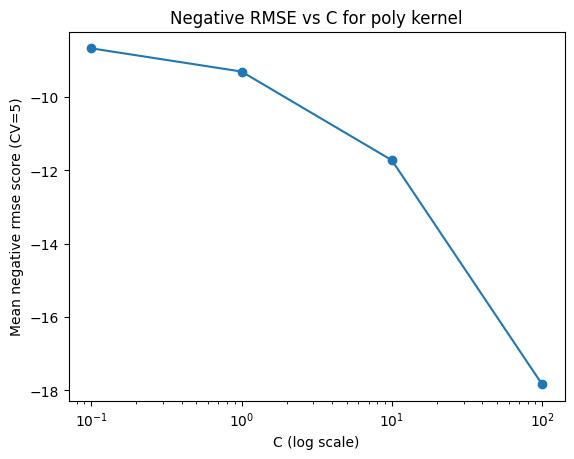

In [68]:
plt.plot(results["param_model__C"], results["mean_test_score"], marker="o")
plt.xlabel("C (log scale)")
plt.ylabel("Mean negative rmse score (CV=5)")
plt.title("Negative RMSE vs C for poly kernel")
plt.xscale("log")
plt.show()

In [ ]:
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    # ("pca", ...),
    ("model", svm_regressor(kernel="poly", C=1.0, degree=2, gamma="scale")),
])

param_grid = {
    "model__degree":[1,2,3,4]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
)

grid_search.fit(X_reg[topK_features], y_reg)

results=pd.DataFrame(grid_search.cv_results_)

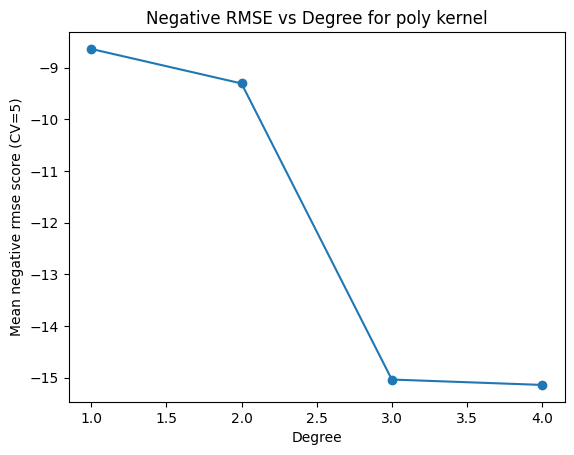

In [70]:
plt.plot(results["param_model__degree"], results["mean_test_score"], marker="o")
plt.xlabel("Degree")
plt.ylabel("Mean negative rmse score (CV=5)")
plt.title("Negative RMSE vs Degree for poly kernel")
plt.show()

In [76]:
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    # ("pca", ...),
    ("model", svm_regressor(kernel="poly", C=1.0, degree=2, gamma="scale")),
])

param_grid = {
    "model__gamma":[0.001,0.01,0.1,1]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
)

grid_search.fit(X_reg[topK_features], y_reg)

results=pd.DataFrame(grid_search.cv_results_)

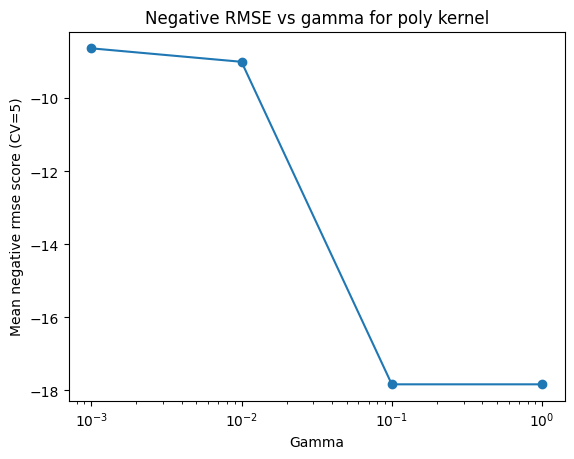

In [77]:
plt.plot(results["param_model__gamma"], results["mean_test_score"], marker="o")
plt.xlabel("Gamma")
plt.ylabel("Mean negative rmse score (CV=5)")
plt.title("Negative RMSE vs gamma for poly kernel")
plt.xscale("log")
plt.show()

In [66]:
# PCA to base
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("model", svm_regressor(kernel="linear", C=1.0, degree=3, gamma="scale")),
])

# apply pca
pipeline.fit(X_train_top_features, y_train)
results = evaluate_regressor(pipeline, X_test_top_features, y_test)
print(results)

y_pred = pipeline.predict(X_test_top_features)
plot_regression_results(y_test, y_pred, "regression_results")
plot_residuals(y_test, y_pred, "residuals")

{'mae': 4.628167096625729, 'rmse': 5.9079526125955635, 'r2': -0.07448285745607675}


In [71]:
# PCA to best model
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("model", svm_regressor(kernel="rbf", C=10, degree=2, gamma=0.001)),
])

# apply pca
pipeline.fit(X_train_top_features, y_train)
results = evaluate_regressor(pipeline, X_test_top_features, y_test)
print(results)

y_pred = pipeline.predict(X_test_top_features)
plot_regression_results(y_test, y_pred, "regression_results")
plot_residuals(y_test, y_pred, "residuals")

{'mae': 4.097249958076784, 'rmse': 5.740274605320048, 'r2': -0.01435698068632174}
